Cosmic Muon Generated by EcoMug
===============================


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def readHepevt(filename):
    particles = []
    with open(filename, 'r') as f:
        while True:
            header = f.readline()
            if not header:
                break  # End of file
            parts = header.strip().split()
            if len(parts) < 3:
                continue
            event_id = int(parts[0])
            vertex_id = int(parts[1])
            n_particles = int(parts[2])
            
            for _ in range(n_particles):
                line = f.readline()
                data = line.strip().split()
                if len(data) < 15:
                    continue
                particle = {
                    "EVENTID": event_id,
                    "VERTEXID": vertex_id,
                    "NParticles": n_particles,
                    "ISTHEP": int(data[0]),
                    "IDHEP": int(data[1]),
                    # "JMOHEP1": int(data[2]),
                    # "JMOHEP2": int(data[3]),
                    # "JDAHEP1": int(data[4]),
                    # "JDAHEP2": int(data[5]),
                    "PHEP1": float(data[6]),
                    "PHEP2": float(data[7]),
                    "PHEP3": float(data[8]),
                    "PHEP4": float(data[9]),
                    "PHEP5": float(data[10]),
                    "VHEP1": float(data[11]),
                    "VHEP2": float(data[12]),
                    "VHEP3": float(data[13]),
                    "VHEP4": float(data[14]),
                }
                particles.append(particle)
    
    events = pd.DataFrame(particles)
    events.columns = ['event_id', 'vertex_id', 'nParticles', 'status', 'pdg_id', 'px', 'py', 'pz', 'E', 'm', 'x', 'y', 'z', 't']
    return events

In [3]:
fName = '/Users/yuntse/data/coherent/SNeNDSens/gen/Cosmics/0000/CosmicFlux_0000.hepevt'

In [4]:
events = readHepevt(fName)
events

,event_id,vertex_id,nParticles,status,pdg_id,px,py,pz,E,m,x,y,z,t
0,0,0,1,1,-13,0.784811,-1.735110,-3.327800,3.835610,0.105658,174.8770,362.3480,241.0,87582.5
1,1,0,1,1,-13,1.068400,-3.050290,-10.271100,10.768100,0.105658,54.9362,226.6920,241.0,187821.0
2,1,1,1,1,-13,-0.729376,-0.438621,-1.749340,1.948270,0.105658,104.4480,269.5270,241.0,191804.0
3,1,2,1,1,13,0.977178,1.617170,-2.635110,3.244240,0.105658,35.2633,106.5080,241.0,191968.0
4,1,3,1,1,-13,-0.483699,0.632073,-0.249658,0.840818,0.105658,372.0420,-285.2940,241.0,191706.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300287,99998,1,1,1,-13,1.181670,-6.225830,-8.696170,10.760700,0.105658,-346.9360,145.4260,241.0,51518.3
300288,99998,2,1,1,13,-6.819270,-2.781250,-1.500120,7.516600,0.105658,-217.7720,-468.4190,241.0,-24525.9
300289,99999,0,1,1,13,0.188433,-1.034440,-3.046470,3.224550,0.105658,327.5180,-82.4239,241.0,-11854.4
300290,99999,1,1,1,13,-1.302510,-1.690210,-26.113700,26.200900,0.105658,276.4250,88.2720,241.0,188780.0


In [ ]:
# Calculate the momentum and cos(theta)
events['p'] = np.sqrt(events['px']**2 + events['py']**2 + events['pz']**2 )
events['costh'] = events['pz']/events['p']

In [6]:
events['p'].min(), events['p'].max(), events['costh'].min(), events['costh'].max()

(0.010005634448513701,
 984.9860934333033,
 -0.9999971691492469,
 -0.01962749805897628)

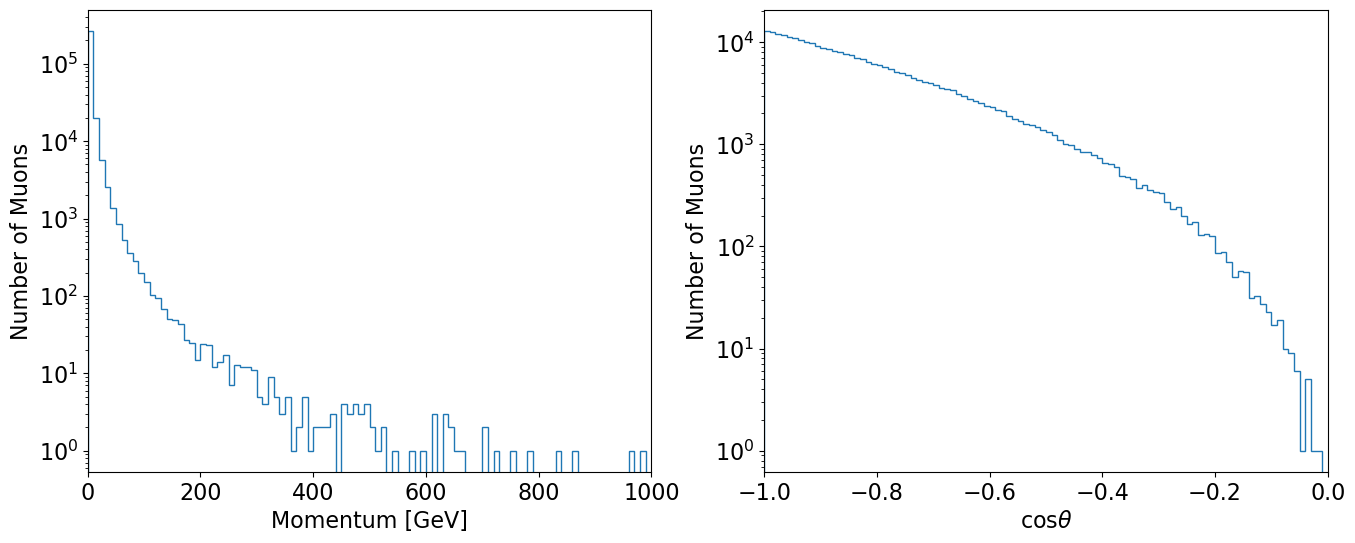

In [7]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))

pBins = np.linspace(0, 1000, 101)
cosBins = np.linspace(-1., 0., 101)
fonts = 16

ax[0].hist(events['p'], bins = pBins, histtype = 'step')
ax[0].set_xlabel('Momentum [GeV]', fontsize = fonts)
ax[0].set_xlim([0, 1000])

ax[1].hist(events['costh'], bins = cosBins, histtype = 'step')
ax[1].set_xlabel(r'cos$\theta$', fontsize = fonts)
ax[1].set_xlim([-1, 0])


for i in range(2):
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].set_yscale('log')
    ax[i].set_ylabel('Number of Muons', fontsize = fonts)


In [9]:
import matplotlib.colors as colors

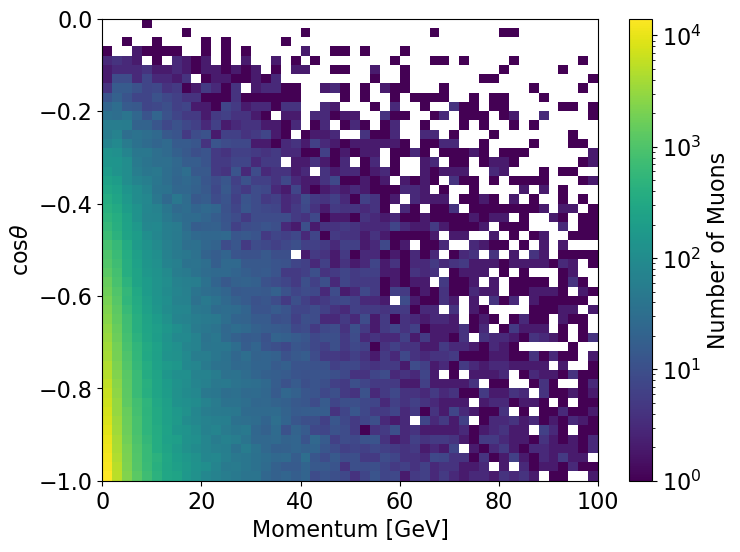

In [12]:
fig, ax = plt.subplots( figsize = (8, 6))

h = ax.hist2d(events['p'], events['costh'], bins = (50, 50), range = [[0, 100], [-1, 0]], cmap = 'viridis', norm = colors.LogNorm())
ax.set_xlabel('Momentum [GeV]', fontsize = fonts)
ax.set_ylabel(r'cos$\theta$', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Muons", fontsize = fonts) 